# Experimental Analysis - LoRA vs Zero-Shot Comparison

Analysis comparing **LoRA fine-tuned** model vs **Ollama zero-shot** baseline.
**Experiments:** Random, Filtered, Mixed

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set_theme(style='whitegrid')

EXP_NAMES = {'experiment_1': 'Random', 'experiment_2': 'Filtered', 'experiment_3': 'Mixed'}
EXP_ORDER = ['Random', 'Filtered', 'Mixed']
MODEL_ORDER = ['ollama', 'lora']
MODEL_LABELS = {'ollama': 'Zero-Shot (Ollama)', 'lora': 'LoRA Fine-tuned'}
MODEL_COLORS = {'ollama': '#e74c3c', 'lora': '#27ae60'}
EXP_COLORS = {'Random': '#3498db', 'Filtered': '#e74c3c', 'Mixed': '#2ecc71'}

base_dir = Path.cwd().parent
results_dir = base_dir / 'results'
plots_dir = results_dir / 'analysis' / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {results_dir}')

Results dir: /home/sing/refactor_project/results


In [2]:
all_results = []
for exp_folder, exp_name in EXP_NAMES.items():
    results_file = results_dir / exp_folder / 'results.json'
    if results_file.exists():
        with open(results_file) as f:
            data = json.load(f)
        for model, commits in data.items():
            for commit in commits:
                commit['experiment'] = exp_name
                commit['model'] = model
                all_results.append(commit)
        print(f"Loaded {exp_name}: ollama={len(data.get('ollama', []))}, lora={len(data.get('lora', []))}")

results_df = pd.DataFrame(all_results)
results_df['model_label'] = results_df['model'].map(MODEL_LABELS)
print(f'\nTotal records: {len(results_df)}')
print(f'Models: {results_df["model"].unique()}')
results_df.head()

Loaded Random: ollama=20, lora=20
Loaded Filtered: ollama=100, lora=100
Loaded Mixed: ollama=71, lora=71

Total records: 382
Models: ['ollama' 'lora']


,sha,compile_ok,smells_before,smells_after,srr,test_pass_rate,attempts,k,experiment,model,model_label
0,d5dee10,False,11,9,18.181818,None,3,1,Random,ollama,Zero-Shot (Ollama)
1,29e73b5,False,70,42,40.000000,None,3,1,Random,ollama,Zero-Shot (Ollama)
2,8d99a79,False,0,0,NaN,None,3,1,Random,ollama,Zero-Shot (Ollama)
3,0a0e66e,False,323,308,4.643963,None,3,1,Random,ollama,Zero-Shot (Ollama)
4,387ae10,False,10,1,90.000000,None,3,1,Random,ollama,Zero-Shot (Ollama)


---
## 1. Smells Before vs After per Experiment

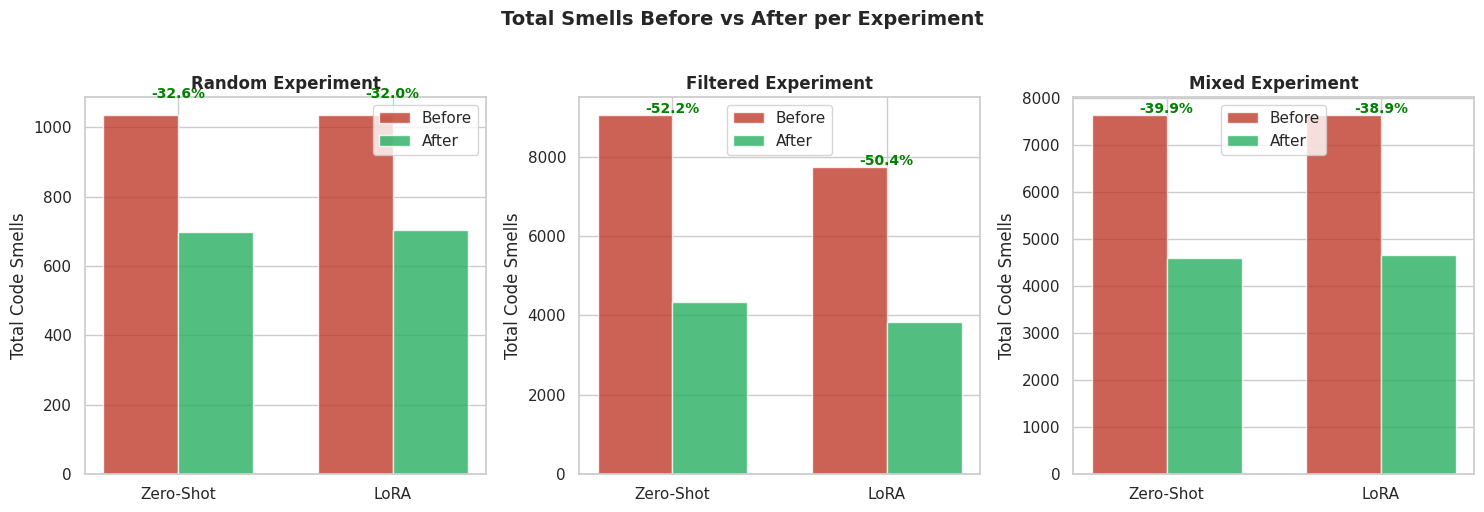

In [3]:
# Total smells before and after per experiment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, exp in zip(axes, EXP_ORDER):
    exp_data = results_df[results_df['experiment'] == exp]
    
    # Group by model
    before_ollama = exp_data[exp_data['model'] == 'ollama']['smells_before'].sum()
    after_ollama = exp_data[exp_data['model'] == 'ollama']['smells_after'].sum()
    before_lora = exp_data[exp_data['model'] == 'lora']['smells_before'].sum()
    after_lora = exp_data[exp_data['model'] == 'lora']['smells_after'].sum()
    
    x = np.arange(2)
    width = 0.35
    
    bars1 = ax.bar(x - width/2, [before_ollama, before_lora], width, label='Before', color='#c0392b', alpha=0.8)
    bars2 = ax.bar(x + width/2, [after_ollama, after_lora], width, label='After', color='#27ae60', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(['Zero-Shot', 'LoRA'])
    ax.set_ylabel('Total Code Smells')
    ax.set_title(f'{exp} Experiment', fontsize=12, fontweight='bold')
    ax.legend()
    
    # Add reduction percentage
    for i, (b, a) in enumerate([(before_ollama, after_ollama), (before_lora, after_lora)]):
        if b > 0:
            reduction = (b - a) / b * 100
            ax.text(i, max(b, a) + 50, f'-{reduction:.1f}%', ha='center', fontsize=10, fontweight='bold', color='green')

plt.suptitle('Total Smells Before vs After per Experiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'smells_before_after_per_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Smell Count (Before and After), Smell-Reduction Distribution (Histograms)

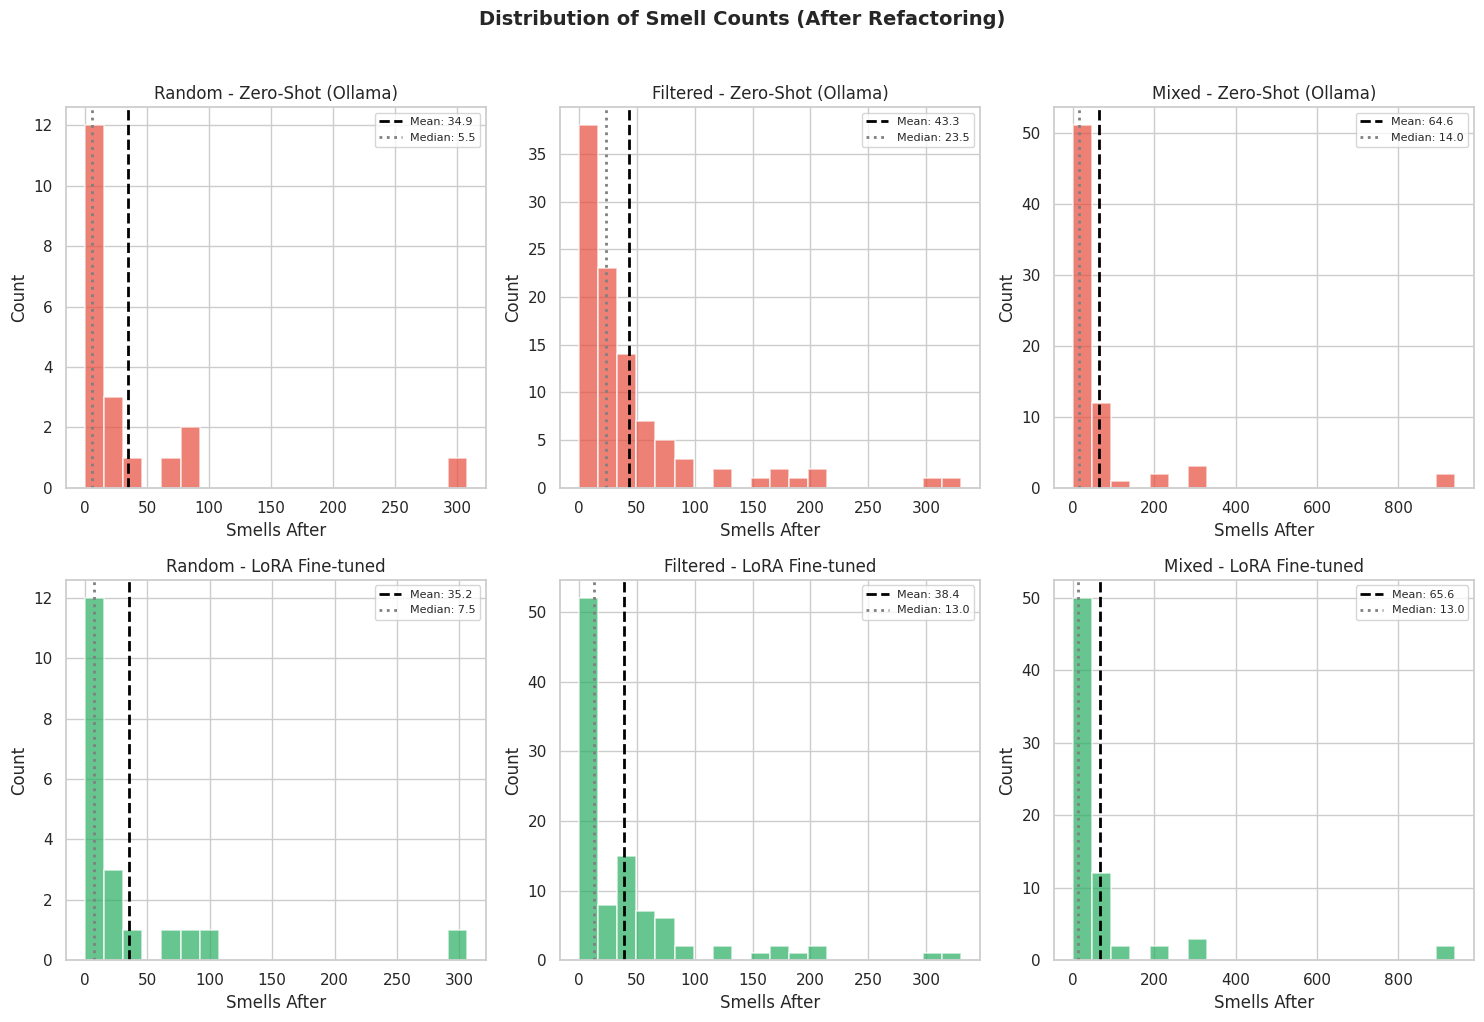

In [4]:
# Histogram of smells_after per experiment and model
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, exp in enumerate(EXP_ORDER):
    exp_data = results_df[results_df['experiment'] == exp]
    
    for row, model in enumerate(MODEL_ORDER):
        ax = axes[row, col]
        smells = exp_data[exp_data['model'] == model]['smells_after']
        
        ax.hist(smells, bins=20, color=MODEL_COLORS[model], alpha=0.7, edgecolor='white', linewidth=1.2)
        ax.axvline(smells.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {smells.mean():.1f}')
        ax.axvline(smells.median(), color='gray', linestyle=':', linewidth=2, label=f'Median: {smells.median():.1f}')
        ax.set_xlabel('Smells After')
        ax.set_ylabel('Count')
        ax.set_title(f'{exp} - {MODEL_LABELS[model]}')
        ax.legend(fontsize=8)

plt.suptitle('Distribution of Smell Counts (After Refactoring)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'smells_after_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

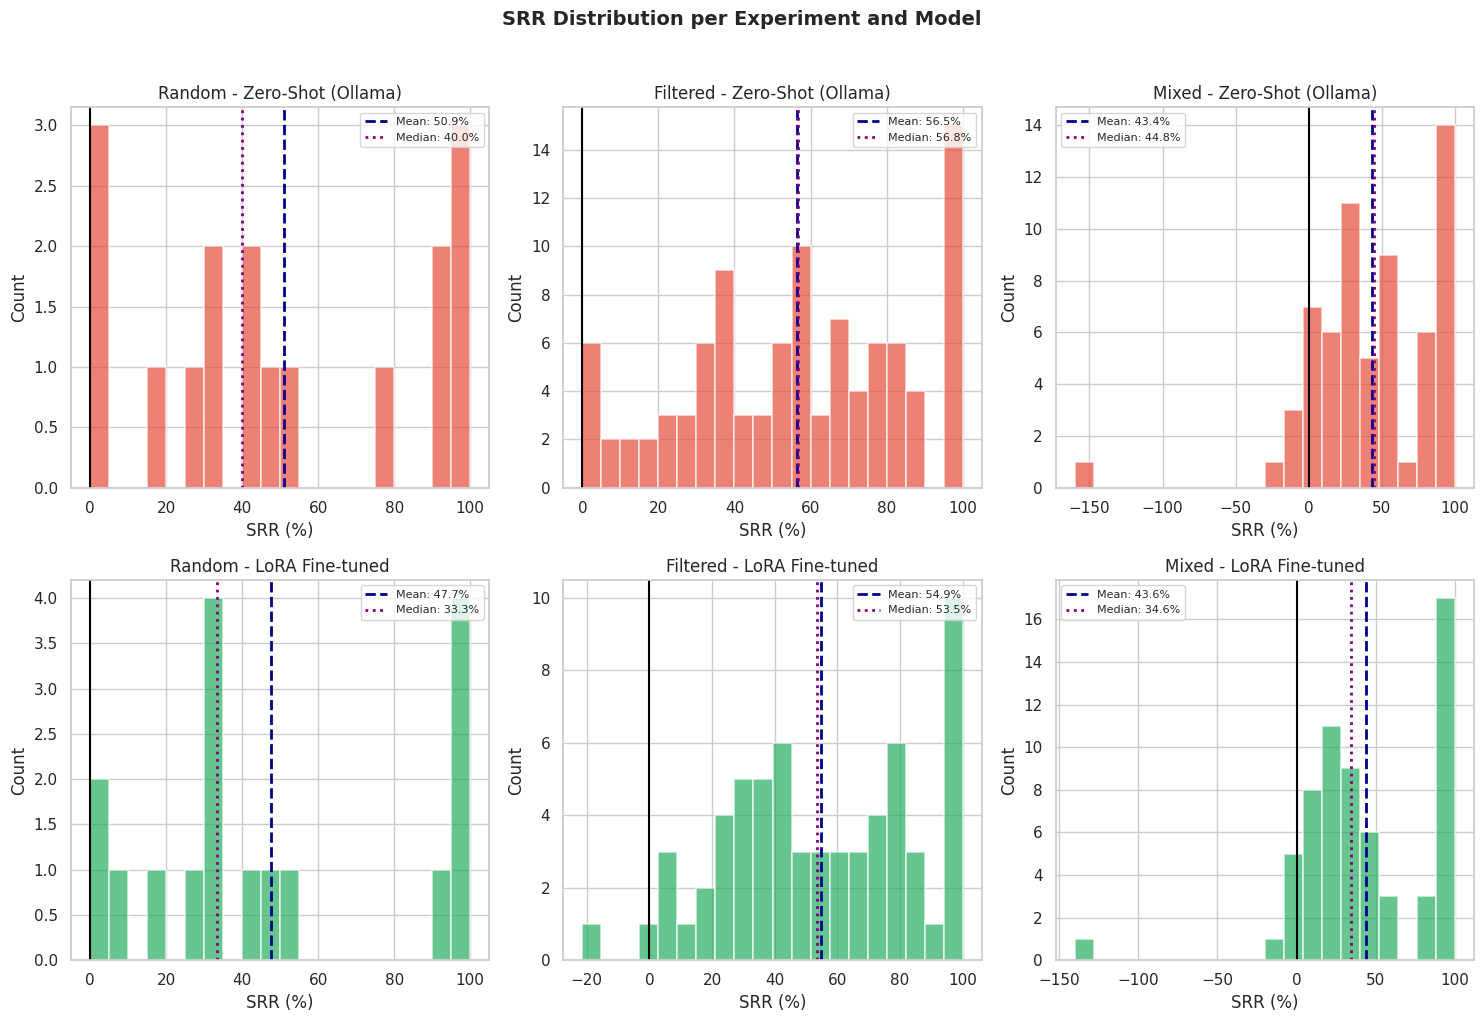

In [5]:
# SRR Histogram per experiment and model
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, exp in enumerate(EXP_ORDER):
    exp_data = results_df[results_df['experiment'] == exp]
    
    for row, model in enumerate(MODEL_ORDER):
        ax = axes[row, col]
        srr = exp_data[exp_data['model'] == model]['srr'].dropna()
        
        ax.hist(srr, bins=20, color=MODEL_COLORS[model], alpha=0.7, edgecolor='white', linewidth=1.2)
        ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
        ax.axvline(srr.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {srr.mean():.1f}%')
        ax.axvline(srr.median(), color='purple', linestyle=':', linewidth=2, label=f'Median: {srr.median():.1f}%')
        ax.set_xlabel('SRR (%)')
        ax.set_ylabel('Count')
        ax.set_title(f'{exp} - {MODEL_LABELS[model]}')
        ax.legend(fontsize=8)

plt.suptitle('SRR Distribution per Experiment and Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'srr_histogram_per_experiment_model.png', dpi=150, bbox_inches='tight')
plt.show()

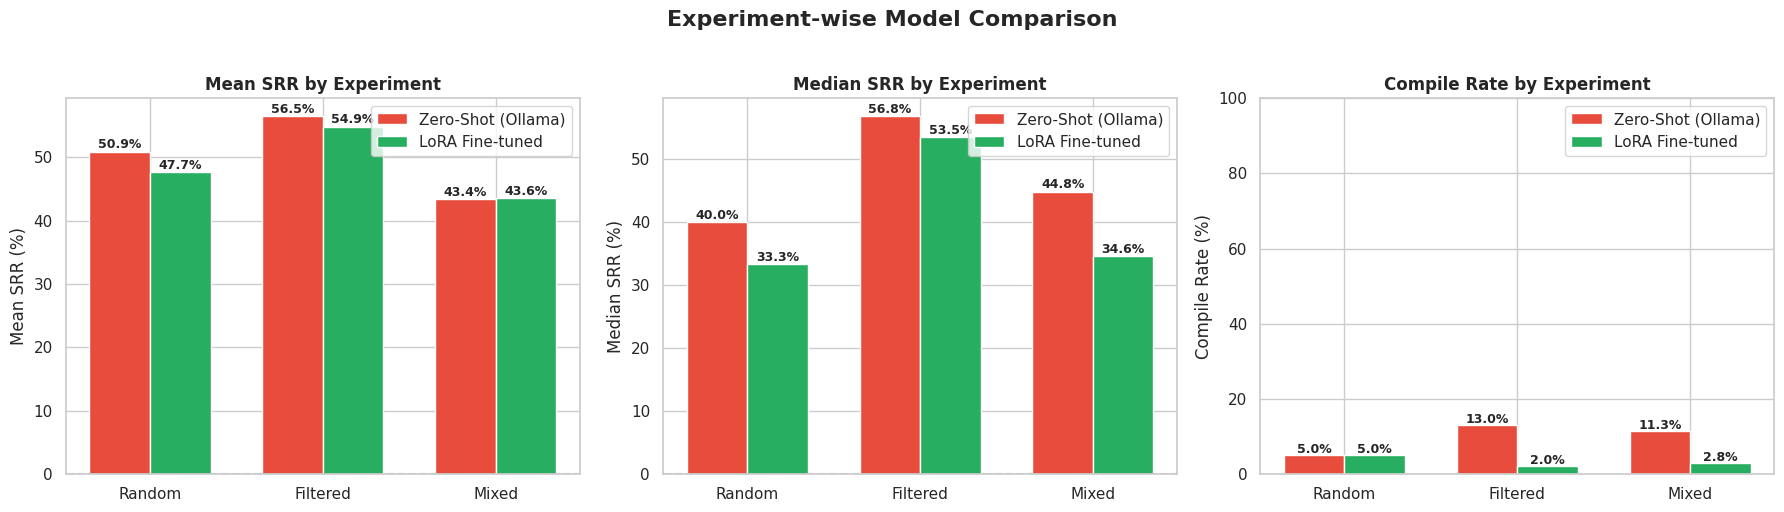

In [6]:
# Experiment-wise comparison: Mean SRR, Median SRR, Compile Rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

exp_model = results_df.groupby(['experiment', 'model']).agg(
    mean_srr=('srr', 'mean'),
    median_srr=('srr', 'median'),
    compile_rate=('compile_ok', 'mean')
).reset_index()
exp_model['compile_rate'] = (exp_model['compile_rate'] * 100).round(1)

x = np.arange(len(EXP_ORDER))
width = 0.35

# 1. Mean SRR
ax = axes[0]
for i, model in enumerate(MODEL_ORDER):
    vals = [exp_model[(exp_model['experiment'] == e) & (exp_model['model'] == model)]['mean_srr'].values[0] for e in EXP_ORDER]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=MODEL_LABELS[model], color=MODEL_COLORS[model])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel('Mean SRR (%)')
ax.set_title('Mean SRR by Experiment', fontweight='bold')
ax.legend()
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# 2. Median SRR
ax = axes[1]
for i, model in enumerate(MODEL_ORDER):
    vals = [exp_model[(exp_model['experiment'] == e) & (exp_model['model'] == model)]['median_srr'].values[0] for e in EXP_ORDER]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=MODEL_LABELS[model], color=MODEL_COLORS[model])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel('Median SRR (%)')
ax.set_title('Median SRR by Experiment', fontweight='bold')
ax.legend()
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# 3. Compile Rate
ax = axes[2]
for i, model in enumerate(MODEL_ORDER):
    vals = [exp_model[(exp_model['experiment'] == e) & (exp_model['model'] == model)]['compile_rate'].values[0] for e in EXP_ORDER]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=MODEL_LABELS[model], color=MODEL_COLORS[model])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel('Compile Rate (%)')
ax.set_title('Compile Rate by Experiment', fontweight='bold')
ax.legend()
ax.set_ylim(0, 100)

plt.suptitle('Experiment-wise Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'experiment_wise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. LoRA vs Zero-Shot: Per Experiment Breakdown

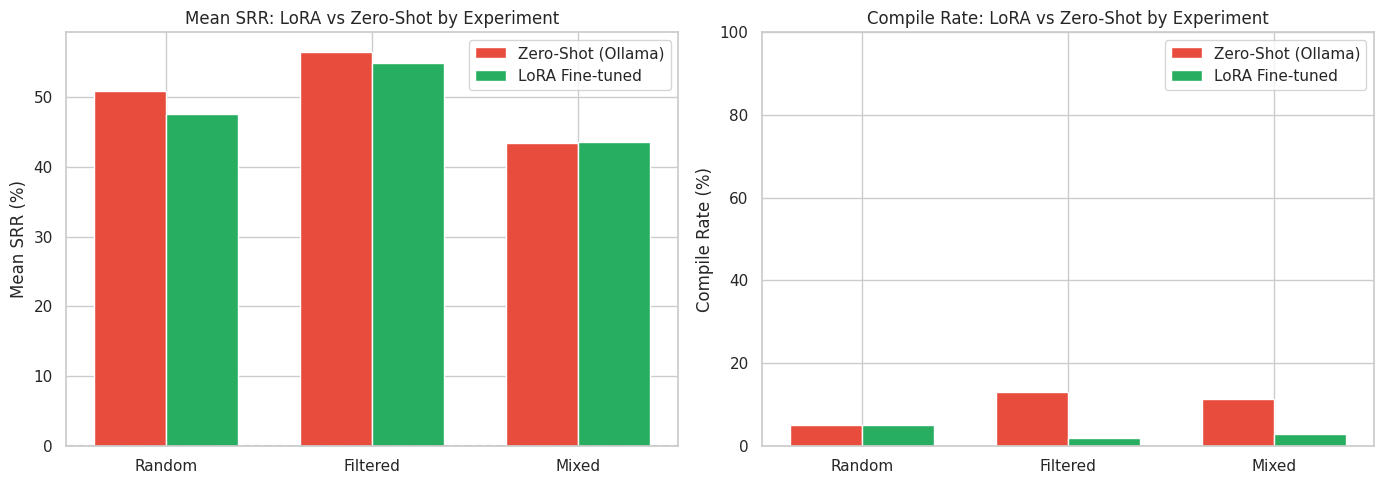

Mean SRR by Experiment and Model:


model,lora,ollama
experiment,,
Random,47.69,50.92
Filtered,54.88,56.52
Mixed,43.63,43.44


In [7]:
# Pivot table: Model x Experiment
pivot_srr = results_df.pivot_table(values='srr', index='experiment', columns='model', aggfunc='mean').reindex(EXP_ORDER)
pivot_compile = results_df.pivot_table(values='compile_ok', index='experiment', columns='model', aggfunc='mean').reindex(EXP_ORDER) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean SRR by Experiment and Model
ax = axes[0]
x = np.arange(len(EXP_ORDER))
width = 0.35
ax.bar(x - width/2, pivot_srr['ollama'], width, label='Zero-Shot (Ollama)', color=MODEL_COLORS['ollama'])
ax.bar(x + width/2, pivot_srr['lora'], width, label='LoRA Fine-tuned', color=MODEL_COLORS['lora'])
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel('Mean SRR (%)')
ax.set_title('Mean SRR: LoRA vs Zero-Shot by Experiment')
ax.legend()
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# Compile Rate by Experiment and Model
ax = axes[1]
ax.bar(x - width/2, pivot_compile['ollama'], width, label='Zero-Shot (Ollama)', color=MODEL_COLORS['ollama'])
ax.bar(x + width/2, pivot_compile['lora'], width, label='LoRA Fine-tuned', color=MODEL_COLORS['lora'])
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel('Compile Rate (%)')
ax.set_title('Compile Rate: LoRA vs Zero-Shot by Experiment')
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(plots_dir / 'lora_vs_zeroshot_by_experiment.png', dpi=150)
plt.show()

print('Mean SRR by Experiment and Model:')
display(pivot_srr.round(2))

---
## 4. Paired Comparison (Same Commits)

In [8]:
# Detailed summary by experiment and model
summary = results_df.groupby(['experiment', 'model']).agg({
    'sha': 'count',
    'compile_ok': ['sum', 'mean'],
    'smells_before': ['sum', 'mean'],
    'smells_after': ['sum', 'mean'],
    'srr': ['mean', 'median', 'std']
}).round(2)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.rename(columns={
    'sha_count': 'n',
    'compile_ok_sum': 'compiled',
    'compile_ok_mean': 'compile_rate'
})
summary['compile_rate'] = (summary['compile_rate'] * 100).round(1)

print('Detailed Summary by Experiment and Model:')
display(summary)

Detailed Summary by Experiment and Model:


n  compiled  compile_rate  smells_before_sum  \
experiment model                                                    
Filtered   lora    100         2           2.0               7748   
           ollama  100        13          13.0               9047   
Mixed      lora     71         2           3.0               7625   
           ollama   71         8          11.0               7625   
Random     lora     20         1           5.0               1035   
           ollama   20         1           5.0               1035   

                   smells_before_mean  smells_after_sum  smells_after_mean  \
experiment model                                                             
Filtered   lora                 77.48              3843              38.43   
           ollama               90.47              4327              43.27   
Mixed      lora                107.39              4658              65.61   
           ollama              107.39              4586              64.59   
Random     lora                 51.75               704              35.20   
           ollama               51.75               698              34.90   

                   srr_mean  srr_median  srr_std  
experiment model                                  
Filtered   lora       54.88       53.47    30.31  
           ollama     56.52       56.81    28.64  
Mixed      lora       43.63       34.58    43.13  
           ollama     43.44       44.85    44.34  
Random     lora       47.69       33.33    36.55  
           ollama     50.92       40.00    35.86

In [9]:
# Compare same SHA across both models
ollama_df = results_df[results_df['model'] == 'ollama'][['sha', 'experiment', 'srr', 'compile_ok', 'smells_before', 'smells_after']]
lora_df = results_df[results_df['model'] == 'lora'][['sha', 'experiment', 'srr', 'compile_ok', 'smells_after']]

paired = ollama_df.merge(lora_df, on=['sha', 'experiment'], suffixes=('_ollama', '_lora'))
print(f'Paired comparisons: {len(paired)} commits')

# Calculate differences
paired['srr_diff'] = paired['srr_lora'] - paired['srr_ollama']  # Positive = LoRA better
paired['lora_wins'] = paired['srr_lora'] > paired['srr_ollama']

print(f"LoRA better: {paired['lora_wins'].sum()} ({paired['lora_wins'].mean()*100:.1f}%)")
print(f"Zero-Shot better: {(~paired['lora_wins']).sum()} ({(~paired['lora_wins']).mean()*100:.1f}%)")
print(f"Mean SRR difference (LoRA - Zero-Shot): {paired['srr_diff'].mean():.2f}%")

Paired comparisons: 191 commits
LoRA better: 32 (16.8%)
Zero-Shot better: 159 (83.2%)
Mean SRR difference (LoRA - Zero-Shot): -0.23%


In [10]:
if timing_data:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Total Duration
    ax = axes[0]
    durations_h = []
    for exp in EXP_ORDER:
        if exp in timing_data:
            durations_h.append(timing_data[exp]['Duration (s)'] / 3600)
    bars = ax.bar(EXP_ORDER, durations_h, color=[EXP_COLORS[e] for e in EXP_ORDER], edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Duration (hours)', fontsize=11)
    ax.set_title('Total Experiment Duration', fontsize=12, fontweight='bold')
    for bar, d in zip(bars, durations_h):
        h = int(d)
        m = int((d - h) * 60)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{h}h {m}m', ha='center', fontweight='bold')

    # 2. Time per Evaluation
    ax = axes[1]
    time_per_eval = [timing_data[e]['Duration (s)'] / timing_data[e]['Total Evaluations'] for e in EXP_ORDER if e in timing_data]
    bars = ax.bar(EXP_ORDER, time_per_eval, color=[EXP_COLORS[e] for e in EXP_ORDER], edgecolor='black', linewidth=1.2)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title('Average Time per Evaluation', fontsize=12, fontweight='bold')
    for bar, t in zip(bars, time_per_eval):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{t:.0f}s', ha='center', fontweight='bold')

    # 3. Evaluations per Experiment (stacked by model)
    ax = axes[2]
    ollama_counts = [timing_data[e]['Eval Commits (Ollama)'] for e in EXP_ORDER if e in timing_data]
    lora_counts = [timing_data[e]['Eval Commits (LoRA)'] for e in EXP_ORDER if e in timing_data]
    x = np.arange(len(EXP_ORDER))
    ax.bar(x, ollama_counts, 0.6, label='Zero-Shot (Ollama)', color=MODEL_COLORS['ollama'], edgecolor='black', linewidth=1.2)
    ax.bar(x, lora_counts, 0.6, bottom=ollama_counts, label='LoRA Fine-tuned', color=MODEL_COLORS['lora'], edgecolor='black', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(EXP_ORDER)
    ax.set_ylabel('Number of Evaluations', fontsize=11)
    ax.set_title('Evaluations per Experiment', fontsize=12, fontweight='bold')
    ax.legend()
    for i, (o, l) in enumerate(zip(ollama_counts, lora_counts)):
        ax.text(i, o + l + 1, str(o + l), ha='center', fontweight='bold')

    plt.suptitle('Experiment Timing & Evaluation Cost', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(plots_dir / 'experiment_timing_output.png', dpi=150, bbox_inches='tight')
    plt.show()

NameError: name 'timing_data' is not defined